# 🛰️ ADCS Simulation – Main Notebook

This notebook controls the full simulation process of an Attitude Determination and Control System (ADCS) for a satellite.  
It ties together all the individual modules and provides plots and insights from the simulation results.

---

## 📂 Project Structure Overview

adcs_sim/  
│  
├── main_simulation.ipynb---# Main simulation controller and visualizer  
│  
├── config.py-----------------# Configuration for satellite, orbit, controller  
├── simulation.py------------# Main simulation loop  
│  
├── orbit.py------------------# Orbital motion model  
├── magnetic_field.py-------# Earth's magnetic field model  
├── attitude.py--------------# Attitude dynamics and kinematics  
├── sensors.py---------------# Simulated gyroscope and magnetometer data  
├── controllers.py-----------# ADCS control algorithms (e.g., B-dot)  
├── filters.py----------------# Orientation filters (e.g., complementary, Kalman)  
└── utils.py------------------# Helper functions and coordinate conversions


---

## 📌 Notebook Responsibilities

- Load configuration parameters from `config.py`
- Initialize satellite orbit, orientation, and sensor models
- Execute the simulation loop (`simulation.py`)
- Run control algorithms (e.g., `B-dot` from `controllers.py`)
- Visualize the results (attitude, angular velocity, control actions, etc.)

---

✅ Use this notebook as the **main entry point** for testing different control laws, noise conditions, and filtering techniques.


In [1]:
from sim import simulate
from config import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # potrzebne dla 3D

In [2]:
# Run main sim
times, positions, velocities = simulate(SIMULATION_TIME, SIMULATION_TIMESTEP)

[6786.137, 0, 0, 0.0, 4.760499390881844, 6.006255426955151]
[[ 6.78613700e+03  6.78570423e+03  6.78440597e+03 ...  6.78567275e+03
   6.78613648e+03  6.78573468e+03]
 [ 0.00000000e+00  4.76039819e+01  9.52018922e+01 ... -4.93070225e+01
  -1.70315325e+00  4.59009333e+01]
 [ 0.00000000e+00  6.00612775e+01  1.20114894e+02 ... -6.22099799e+01
  -2.14884461e+00  5.79125648e+01]
 [ 0.00000000e+00 -8.65532859e-02 -1.73095532e-01 ...  8.96497433e-02
   3.09666339e-03 -8.34568119e-02]
 [ 4.76049939e+00  4.76019580e+00  4.75928507e+00 ...  4.76017368e+00
   4.76049899e+00  4.76021712e+00]
 [ 6.00625543e+00  6.00587239e+00  6.00472333e+00 ...  6.00584448e+00
   6.00625492e+00  6.00589929e+00]]


In [3]:
print(times)
print(positions)
print(velocities)
print(MU_EARTH)
print(ORBIT_PERIOD)

[0.000e+00 1.000e+01 2.000e+01 ... 1.668e+04 1.669e+04 1.670e+04]
[[ 6.78613700e+03  0.00000000e+00  0.00000000e+00]
 [ 6.78570423e+03  4.76039819e+01  6.00612775e+01]
 [ 6.78440597e+03  9.52018922e+01  1.20114894e+02]
 ...
 [ 6.78567275e+03 -4.93070225e+01 -6.22099799e+01]
 [ 6.78613648e+03 -1.70315325e+00 -2.14884461e+00]
 [ 6.78573468e+03  4.59009333e+01  5.79125648e+01]]
[[ 0.00000000e+00  4.76049939e+00  6.00625543e+00]
 [-8.65532859e-02  4.76019580e+00  6.00587239e+00]
 [-1.73095532e-01  4.75928507e+00  6.00472333e+00]
 ...
 [ 8.96497433e-02  4.76017368e+00  6.00584448e+00]
 [ 3.09666339e-03  4.76049899e+00  6.00625492e+00]
 [-8.34568119e-02  4.76021712e+00  6.00589929e+00]]
398600.4418
5563.459296958976


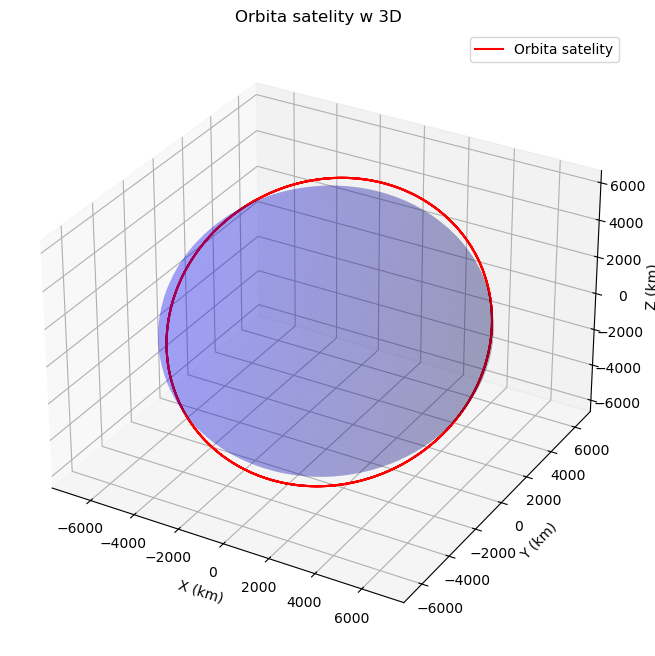

In [ ]:
# Tworzenie wykresu
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Wykres orbity
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], label='Orbita satelity', color='red')

# Wykres Ziemi jako kula
R_EARTH = 6378.12  # km
u, v = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x = R_EARTH * np.outer(np.cos(u), np.sin(v))
y = R_EARTH * np.outer(np.sin(u), np.sin(v))
z = R_EARTH * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='blue', alpha=0.2)

# Ustawienia osi
ax.set_title("Orbita satelity w 3D")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
ax.set_box_aspect([1, 1, 0.8])  # Równe proporcje osi
plt.show()